# <span style="font-width:bold; font-size: 3rem; color:#1EB182;"> **Air Quality** </span><span style="font-width:bold; font-size: 3rem; color:#333;">- Part 04: Multi-Day Batch Inference</span>

## 🗒️ This notebook is divided into the following sections:

1. Download model and batch inference data
2. Make multi-day predictions, generate PNG for forecast
3. Store predictions in a monitoring feature group and generate PNG for hindcast

## <span style='color:#ff5f27'> 📝 Imports

In [1]:
import sys
from pathlib import Path

def is_google_colab() -> bool:
    if "google.colab" in str(get_ipython()):
        return True
    return False

def clone_repository() -> None:
    !git clone https://github.com/featurestorebook/mlfs-book.git
    %cd mlfs-book

def install_dependencies() -> None:
    !pip install --upgrade uv
    !uv pip install --all-extras --system --requirement pyproject.toml


if is_google_colab():
    clone_repository()
    install_dependencies()
    root_dir = str(Path().absolute())
    print("Google Colab environment")
else:
    root_dir = Path().absolute()
    # Strip ~/notebooks/ccfraud from PYTHON_PATH if notebook started in one of these subdirectories
    if root_dir.parts[-1:] == ('airquality',):
        root_dir = Path(*root_dir.parts[:-1])
    if root_dir.parts[-1:] == ('notebooks',):
        root_dir = Path(*root_dir.parts[:-1])
    root_dir = str(root_dir) 
    print("Local environment")

# Add the root directory to the `PYTHONPATH` to use the `recsys` Python module from the notebook.
if root_dir not in sys.path:
    sys.path.append(root_dir)
print(f"Added the following directory to the PYTHONPATH: {root_dir}")
    
# Read the API keys and configuration variables from the file <root_dir>/.env
from mlfs import config
settings = config.HopsworksSettings(_env_file=f"{root_dir}/.env")

Local environment
Added the following directory to the PYTHONPATH: /Users/hongjiang/git/mlfs-book
HopsworksSettings initialized!


In [2]:
import datetime
import pandas as pd
from xgboost import XGBRegressor
import hopsworks
import json
from mlfs.airquality import util
import os

## <span style='color:#ff5f27'> 🔧 Configuration: Set Forecast Days</span>

In [3]:
# Configuration: Set number of days to forecast (can be changed to 3, 7, 14, etc.)
# You can also set this in your .env file as FORECAST_DAYS=7
FORECAST_DAYS = int(os.getenv('FORECAST_DAYS', 7))
print(f"Will forecast for the next {FORECAST_DAYS} days")

Will forecast for the next 7 days


In [4]:
today = datetime.datetime.now() - datetime.timedelta(0)
# Generate list of dates for the next N days
forecast_dates = [today + datetime.timedelta(days=i) for i in range(1, FORECAST_DAYS + 1)]
print(f"Forecast dates: {[d.strftime('%Y-%m-%d') for d in forecast_dates]}")

Forecast dates: ['2025-11-19', '2025-11-20', '2025-11-21', '2025-11-22', '2025-11-23', '2025-11-24', '2025-11-25']


## <span style="color:#ff5f27;"> 📡 Connect to Hopsworks Feature Store </span>

In [5]:
project = hopsworks.login(engine="python")
fs = project.get_feature_store() 

secrets = hopsworks.get_secrets_api()
location_str = secrets.get_secret("SENSOR_LOCATION_JSON").value
location = json.loads(location_str)
country=location['country']
city=location['city']
street=location['street']

2025-11-18 18:31:18,468 INFO: Initializing external client
2025-11-18 18:31:18,469 INFO: Base URL: https://c.app.hopsworks.ai:443
2025-11-18 18:31:19,185 WARNING: UserWarning: The installed hopsworks client version 4.4.2 may not be compatible with the connected Hopsworks backend version 4.2.2. 
To ensure compatibility please install the latest bug fix release matching the minor version of your backend (4.2) by running 'pip install hopsworks==4.2.*'



2025-11-18 18:31:20,092 INFO: Python Engine initialized.

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1292436


## <span style="color:#ff5f27;">🪝 Download the model from Model Registry</span>

In [6]:
mr = project.get_model_registry()

retrieved_model = mr.get_model(
    name="air_quality_xgboost_model",
    version=1,
)

fv = retrieved_model.get_feature_view()

# Download the saved model artifacts to a local directory
saved_model_dir = retrieved_model.download()

2025-11-18 18:31:24,887 INFO: Initializing for batch retrieval of feature vectors


Downloading: 0.000%|          | 0/440124 elapsed<00:00 remaining<?

Downloading: 0.000%|          | 0/121919 elapsed<00:00 remaining<?

Downloading: 0.000%|          | 0/152903 elapsed<00:00 remaining<?

Downloading: 0.000%|          | 0/119410 elapsed<00:00 remaining<?

Downloading: 0.000%|          | 0/19818 elapsed<00:00 remaining<?

In [7]:
# Loading the XGBoost regressor model and label encoder from the saved model directory
retrieved_xgboost_model = XGBRegressor()

retrieved_xgboost_model.load_model(saved_model_dir + "/model.json")

# Displaying the retrieved XGBoost regressor model
retrieved_xgboost_model

XGBRegressor(base_score='2.8458775E1', booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None,
             feature_types=['float', 'float', 'float', 'float'], gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

## <span style="color:#ff5f27;">✨ Get Weather Forecast Features for Multiple Days</span>



In [8]:
weather_fg = fs.get_feature_group(
    name='weather',
    version=1,
)

# Get all weather data from today to the last forecast date
last_forecast_date = forecast_dates[-1]
batch_data = weather_fg.filter(weather_fg.date >= today).filter(weather_fg.date <= last_forecast_date).read()
batch_data

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.86s) 


,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city
0,2025-11-22 00:00:00+00:00,1.95,0.0,9.726664,218.990997,visby
1,2025-11-19 00:00:00+00:00,1.55,0.0,3.600000,360.000000,visby
2,2025-11-23 00:00:00+00:00,3.10,0.0,6.696387,233.746063,visby
3,2025-11-24 00:00:00+00:00,3.95,0.1,10.495713,67.833611,visby
4,2025-11-20 00:00:00+00:00,1.35,0.8,6.214563,100.007919,visby
5,2025-11-21 00:00:00+00:00,3.05,0.2,16.800856,315.000092,visby


### <span style="color:#ff5f27;">🤖 Making Multi-Day Predictions</span>

In [9]:
# Make predictions for all retrieved data
batch_data['predicted_pm25'] = retrieved_xgboost_model.predict(
    batch_data[['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'wind_direction_10m_dominant']])
batch_data

,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city,predicted_pm25
0,2025-11-22 00:00:00+00:00,1.95,0.0,9.726664,218.990997,visby,38.359734
1,2025-11-19 00:00:00+00:00,1.55,0.0,3.600000,360.000000,visby,29.533037
2,2025-11-23 00:00:00+00:00,3.10,0.0,6.696387,233.746063,visby,48.693336
3,2025-11-24 00:00:00+00:00,3.95,0.1,10.495713,67.833611,visby,14.969270
4,2025-11-20 00:00:00+00:00,1.35,0.8,6.214563,100.007919,visby,27.074820
5,2025-11-21 00:00:00+00:00,3.05,0.2,16.800856,315.000092,visby,12.566618


In [10]:
batch_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype                  
---  ------                       --------------  -----                  
 0   date                         6 non-null      datetime64[us, Etc/UTC]
 1   temperature_2m_mean          6 non-null      float32                
 2   precipitation_sum            6 non-null      float32                
 3   wind_speed_10m_max           6 non-null      float32                
 4   wind_direction_10m_dominant  6 non-null      float32                
 5   city                         6 non-null      object                 
 6   predicted_pm25               6 non-null      float32                
dtypes: datetime64[us, Etc/UTC](1), float32(5), object(1)
memory usage: 344.0+ bytes


### <span style="color:#ff5f27;">🤖 Saving the predictions (for monitoring) to a Feature Group</span>

In [11]:
batch_data['street'] = street
batch_data['city'] = city
batch_data['country'] = country
# Fill in the number of days before the date on which you made the forecast (base_date)
batch_data['days_before_forecast_day'] = range(1, len(batch_data)+1)
batch_data = batch_data.sort_values(by=['date'])
batch_data

,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant,city,predicted_pm25,street,country,days_before_forecast_day
1,2025-11-19 00:00:00+00:00,1.55,0.0,3.600000,360.000000,visby,29.533037,visby-ostervag-17,sweden,2
4,2025-11-20 00:00:00+00:00,1.35,0.8,6.214563,100.007919,visby,27.074820,visby-ostervag-17,sweden,5
5,2025-11-21 00:00:00+00:00,3.05,0.2,16.800856,315.000092,visby,12.566618,visby-ostervag-17,sweden,6
0,2025-11-22 00:00:00+00:00,1.95,0.0,9.726664,218.990997,visby,38.359734,visby-ostervag-17,sweden,1
2,2025-11-23 00:00:00+00:00,3.10,0.0,6.696387,233.746063,visby,48.693336,visby-ostervag-17,sweden,3
3,2025-11-24 00:00:00+00:00,3.95,0.1,10.495713,67.833611,visby,14.969270,visby-ostervag-17,sweden,4


In [12]:
batch_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, 1 to 3
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype                  
---  ------                       --------------  -----                  
 0   date                         6 non-null      datetime64[us, Etc/UTC]
 1   temperature_2m_mean          6 non-null      float32                
 2   precipitation_sum            6 non-null      float32                
 3   wind_speed_10m_max           6 non-null      float32                
 4   wind_direction_10m_dominant  6 non-null      float32                
 5   city                         6 non-null      object                 
 6   predicted_pm25               6 non-null      float32                
 7   street                       6 non-null      object                 
 8   country                      6 non-null      object                 
 9   days_before_forecast_day     6 non-null      int64                  
dtypes: datetime

### Create Multi-Day Forecast Graph
Draw a graph of the predictions with dates as a PNG and save it to the github repo
Show it on github pages

2025-11-18 18:31:33,105 WARNING: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.



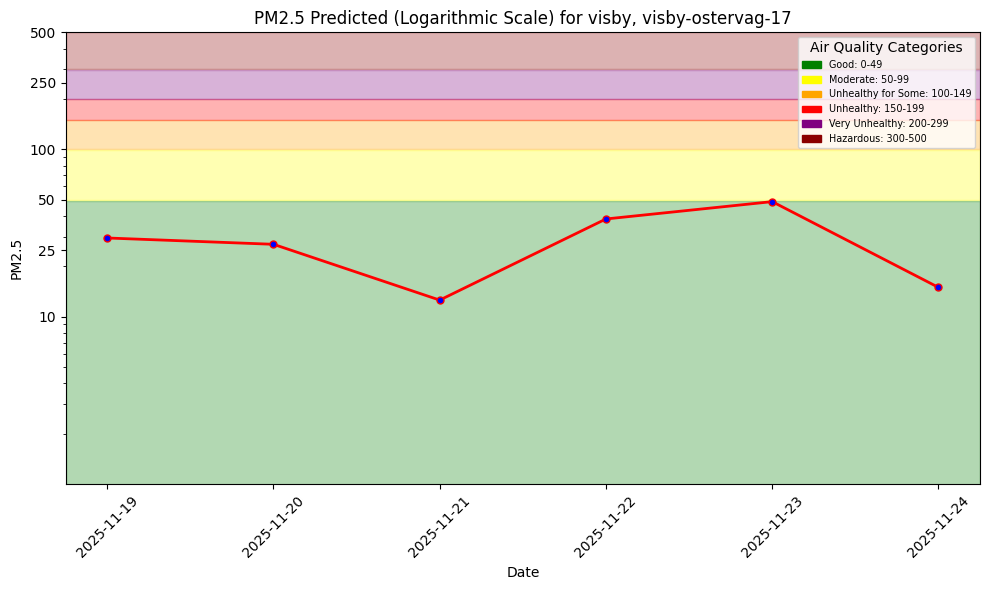

In [13]:
pred_file_path = f"{root_dir}/docs/air-quality/assets/img/pm25_forecast_{FORECAST_DAYS}day.png"
plt = util.plot_air_quality_forecast(city, street, batch_data, pred_file_path)

plt.show()

In [14]:
# Get or create feature group
monitor_fg = fs.get_or_create_feature_group(
    name='aq_predictions',
    description='Air Quality prediction monitoring',
    version=1,
    primary_key=['city','street','date','days_before_forecast_day'],
    event_time="date"
)

In [15]:
monitor_fg.insert(batch_data, wait=True)

Uploading Dataframe: 100.00% |█| Rows 6/6 | Elapsed Time: 00:01 | Remaining Time


Launching job: aq_predictions_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://c.app.hopsworks.ai:443/p/1292436/jobs/named/aq_predictions_1_offline_fg_materialization/executions
2025-11-18 18:31:51,249 INFO: Waiting for execution to finish. Current state: SUBMITTED. Final status: UNDEFINED
2025-11-18 18:31:54,451 INFO: Waiting for execution to finish. Current state: RUNNING. Final status: UNDEFINED
2025-11-18 18:33:14,411 INFO: Waiting for execution to finish. Current state: AGGREGATING_LOGS. Final status: SUCCEEDED
2025-11-18 18:33:14,586 INFO: Waiting for log aggregation to finish.
2025-11-18 18:33:23,284 INFO: Execution finished successfully.


(Job('aq_predictions_1_offline_fg_materialization', 'SPARK'), None)

### <span style="color:#ff5f27;">📊 Compare Historical Data with Predictions</span>

In [16]:
# Get actual data from the past 7 days for comparison
air_quality_fg = fs.get_feature_group(name='air_quality', version=1)
historical_start = today - datetime.timedelta(days=7)
historical_data = air_quality_fg.filter(air_quality_fg.date >= historical_start).filter(air_quality_fg.date <= today).read()

print(f"Historical data from {historical_start.strftime('%Y-%m-%d')} to {today.strftime('%Y-%m-%d')}")
historical_data

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.01s) 
Historical data from 2025-11-11 to 2025-11-18


,date,pm25,country,city,street,url
0,2025-11-18 00:00:00+00:00,12.0,sweden,visby,visby-ostervag-17,https://api.waqi.info/feed/@13987


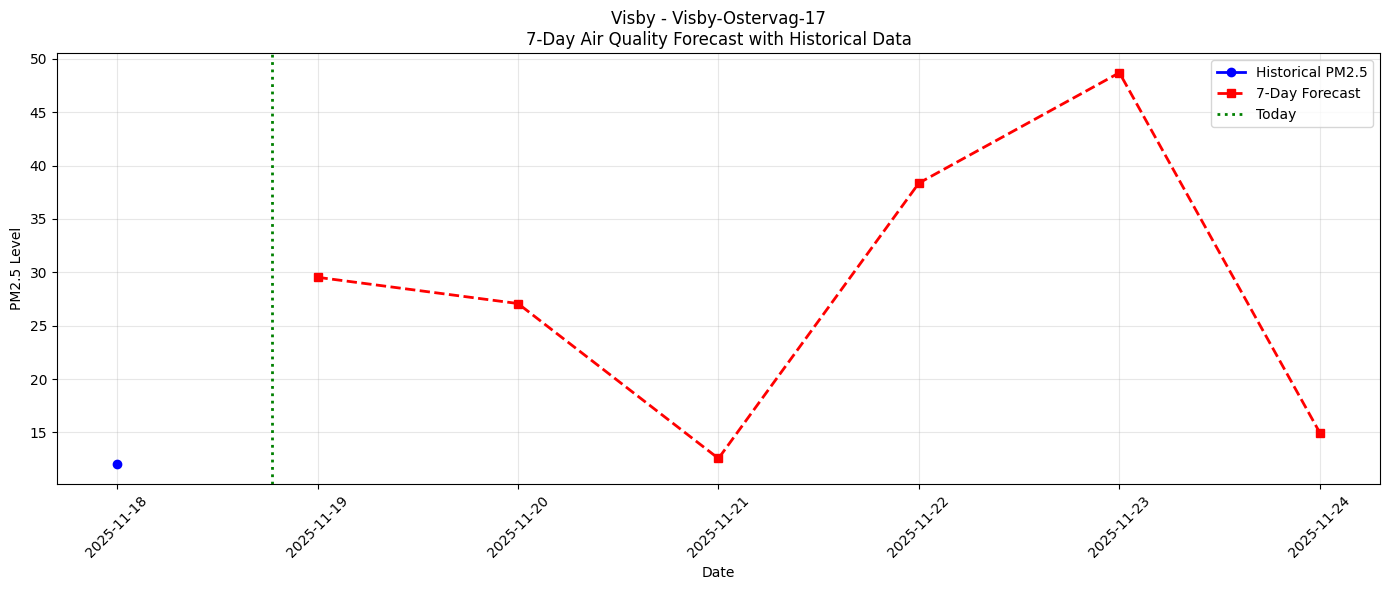

Combined chart saved to: /Users/hongjiang/git/mlfs-book/docs/air-quality/assets/img/pm25_combined_7day.png


In [17]:
# Create combined chart with historical and forecast data
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot historical data
if not historical_data.empty:
    plt.plot(historical_data['date'], historical_data['pm25'], 
             label='Historical PM2.5', marker='o', color='blue', linewidth=2)

# Plot forecast data
plt.plot(batch_data['date'], batch_data['predicted_pm25'], 
         label=f'{FORECAST_DAYS}-Day Forecast', marker='s', color='red', 
         linestyle='--', linewidth=2)

# Add today's dividing line
plt.axvline(x=today, color='green', linestyle=':', linewidth=2, label='Today')

plt.xlabel('Date')
plt.ylabel('PM2.5 Level')
plt.title(f'{city.title()} - {street.title()}\n{FORECAST_DAYS}-Day Air Quality Forecast with Historical Data')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the chart
combined_file_path = f"{root_dir}/docs/air-quality/assets/img/pm25_combined_{FORECAST_DAYS}day.png"
plt.savefig(combined_file_path)
plt.show()

print(f"Combined chart saved to: {combined_file_path}")

### Upload the prediction dashboards (png files) to Hopsworks


In [18]:
dataset_api = project.get_dataset_api()
str_today = today.strftime("%Y-%m-%d")
if dataset_api.exists("Resources/airquality") == False:
    dataset_api.mkdir("Resources/airquality")
dataset_api.upload(pred_file_path, f"Resources/airquality/{city}_{street}_{str_today}", overwrite=True)
dataset_api.upload(combined_file_path, f"Resources/airquality/{city}_{street}_{str_today}", overwrite=True)

proj_url = project.get_url()
print(f"See images in Hopsworks here: {proj_url}/settings/fb/path/Resources/airquality")

Uploading /Users/hongjiang/git/mlfs-book/docs/air-quality/assets/img/pm25_forecast_7day.png: 0.000%|          …

Uploading /Users/hongjiang/git/mlfs-book/docs/air-quality/assets/img/pm25_combined_7day.png: 0.000%|          …

See images in Hopsworks here: https://c.app.hopsworks.ai:443/p/1292436/settings/fb/path/Resources/airquality


## <span style='color:#ff5f27'> 📈 Summary Statistics</span>

In [19]:
# Display forecast statistics
print(f"\n=== {FORECAST_DAYS}-Day Forecast Summary ===")
print(f"Average predicted PM2.5: {batch_data['predicted_pm25'].mean():.2f}")
print(f"Maximum predicted PM2.5: {batch_data['predicted_pm25'].max():.2f}")
print(f"Minimum predicted PM2.5: {batch_data['predicted_pm25'].min():.2f}")
print(f"\nForecast period: {forecast_dates[0].strftime('%Y-%m-%d')} to {forecast_dates[-1].strftime('%Y-%m-%d')}")


=== 7-Day Forecast Summary ===
Average predicted PM2.5: 28.53
Maximum predicted PM2.5: 48.69
Minimum predicted PM2.5: 12.57

Forecast period: 2025-11-19 to 2025-11-25


---